In [58]:
import numpy as np
import pandas as pd

In [59]:
df = pd.read_csv("/content/placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [60]:
df.shape

(100, 4)

In [61]:
df.columns

Index(['Unnamed: 0', 'cgpa', 'iq', 'placement'], dtype='object')

## What we will be performing in this module -
- Preprocess + EDA + Feature Selection
- extract input and output cols
- scale the values
- train test split
- train the model
- evaluate the model
- deploy the model



In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [63]:
df.isna().sum()

,0
Unnamed: 0,0
cgpa,0
iq,0
placement,0


In [64]:
df_processed = df.drop(columns=["Unnamed: 0"], axis = 1)

In [65]:
df_processed

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


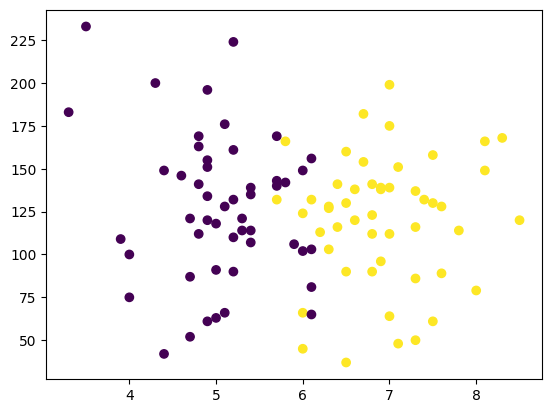

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df_processed['cgpa'], df_processed['iq'], c=df_processed['placement'])

In [67]:
X = df_processed.drop(columns=["placement"]) #independent column
y = df_processed['placement']                #dependent column

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)         #dont need to fit again, as patter is already recognised, so we transform



In [70]:
# model training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [71]:
y_pred = model.predict(X_test_scaled)

In [72]:
y_test

,placement
83,1
53,1
70,1
45,1
44,1
39,0
22,0
80,0
10,1
0,1


In [73]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.85

In [74]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[9, 1],
       [2, 8]])

In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



In [76]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred)

np.float64(0.8500000000000001)

<Axes: >

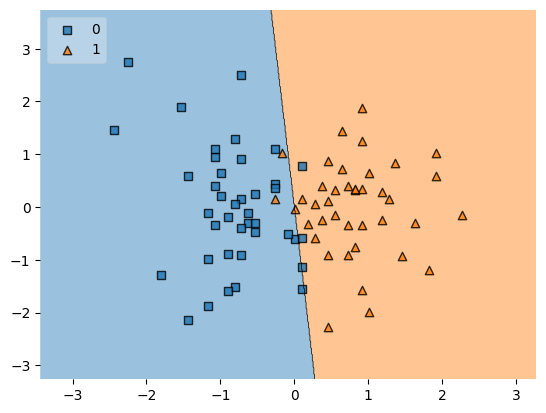

In [77]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X_train_scaled, y=y_train.values, clf=model,legend=2)


In [78]:
import pickle
pickle.dump(model, open("placement_model.pkl","wb"))